In [12]:
from forestkernel import ForestKernel
from sklearn.model_selection import train_test_split

import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))
from dataset import dataprep

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
import time
import numpy as np
from sklearn.decomposition import PCA
from openTSNE import TSNE



from time import time

In [13]:
import time
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from umap import UMAP

timings = {}

# ---------------------------------------------------------
# Load + prepare data
# ---------------------------------------------------------
t0 = time.perf_counter()
data = pd.read_parquet('/NOBACKUP/aumona/projects/RF-GAP-Python/data/sign_mnist_train.parquet')
timings["Load parquet"] = time.perf_counter() - t0

t0 = time.perf_counter()
x, y = dataprep(data, scale='normalize', drop_missing_y=True, global_transform=True)
y = np.asarray(y)
timings["dataprep"] = time.perf_counter() - t0

seed = 42

t0 = time.perf_counter()
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=seed,
    stratify=y,
)
timings["train_test_split"] = time.perf_counter() - t0

print(x,y)

Initial shape: (27455, 785)
Missing labels handling: removed 0 row(s) with missing values in 'label'.
Label column: 'label'
Label handling: kept categorical/string labels as strings.
Number of classes: 24
No categorical feature columns to factorize.
Scaling: globally normalized all feature values to [0, 1].
Final feature shape: (27455, 784)
[[0.41960785 0.4627451  0.49803922 ... 0.8        0.79607844 0.7921569 ]
 [0.60784316 0.6156863  0.6117647  ... 0.40392157 0.5294118  0.58431375]
 [0.73333335 0.7372549  0.7372549  ... 0.7647059  0.7607843  0.7647059 ]
 ...
 [0.68235296 0.68235296 0.68235296 ... 0.7921569  0.78431374 0.78431374]
 [0.69411767 0.70980394 0.72156864 ... 0.2509804  0.34117648 0.3647059 ]
 [0.7019608  0.7058824  0.7058824  ... 0.8039216  0.81960785 0.84313726]] ['D' 'G' 'C' ... 'S' 'R' 'X']


In [14]:
# ---------------------------------------------------------
# Fit kernel on training data
# ---------------------------------------------------------
t0 = time.perf_counter()
fk = ForestKernel(kernel_method='kerf', model_type='rf', random_state=seed)
fk.fit(x_train, y_train)
timings["ForestKernel.fit"] = time.perf_counter() - t0

t0 = time.perf_counter()
leaf_emb_train = fk.get_reference_map()
timings["get_reference_map"] = time.perf_counter() - t0

t0 = time.perf_counter()
leaf_emb_test = fk.get_query_map(x_test)
timings["get_query_map(test)"] = time.perf_counter() - t0

print("Train leaf embedding shape:", leaf_emb_train.shape)
print("Test leaf embedding shape:", leaf_emb_test.shape)
print("Train leaf embedding type:", type(leaf_emb_train))
print("Test leaf embedding type:", type(leaf_emb_test))

Train leaf embedding shape: (21964, 471830)
Test leaf embedding shape: (5491, 471830)
Train leaf embedding type: <class 'scipy.sparse._csr.csr_matrix'>
Test leaf embedding type: <class 'scipy.sparse._csr.csr_matrix'>


In [15]:
# ---------------------------------------------------------
# 2D embeddings fit on train only, then transform test
# ---------------------------------------------------------

# Raw PCA
t0 = time.perf_counter()
raw_pca = PCA(n_components=2, random_state=seed)
x_pca_raw_train = raw_pca.fit_transform(x_train)
x_pca_raw_test = raw_pca.transform(x_test)
timings["Raw PCA"] = time.perf_counter() - t0

# Leaf PCA
t0 = time.perf_counter()
leaf_pca = PCA(n_components=2, random_state=seed)
x_pca_leaf_train = leaf_pca.fit_transform(leaf_emb_train)
x_pca_leaf_test = leaf_pca.transform(leaf_emb_test)
timings["Leaf PCA"] = time.perf_counter() - t0

# Raw TruncatedSVD(30) + UMAP
t0 = time.perf_counter()
raw_svd30 = TruncatedSVD(n_components=30, random_state=seed)
x_raw_svd30_train = raw_svd30.fit_transform(x_train)
x_raw_svd30_test = raw_svd30.transform(x_test)

raw_umap = UMAP(n_components=2, random_state=None)
x_umap_raw_train = raw_umap.fit_transform(x_raw_svd30_train)
x_umap_raw_test = raw_umap.transform(x_raw_svd30_test)
timings["Raw SVD30 + UMAP"] = time.perf_counter() - t0

# Leaf TruncatedSVD(30) + UMAP
t0 = time.perf_counter()
leaf_svd30 = TruncatedSVD(n_components=30, random_state=seed)
x_leaf_svd30_train = leaf_svd30.fit_transform(leaf_emb_train)
x_leaf_svd30_test = leaf_svd30.transform(leaf_emb_test)

leaf_umap = UMAP(n_components=2, random_state=None)
x_umap_leaf_train = leaf_umap.fit_transform(x_leaf_svd30_train)
x_umap_leaf_test = leaf_umap.transform(x_leaf_svd30_test)
timings["Leaf SVD30 + UMAP"] = time.perf_counter() - t0

In [16]:
# ---------------------------------------------------------
# 5-NN evaluation
# ---------------------------------------------------------
knn = KNeighborsClassifier(n_neighbors=5)

def eval_knn(xtr, xte, ytr, yte):
    knn.fit(xtr, ytr)
    return knn.score(xte, yte)

score_raw_pca = eval_knn(x_pca_raw_train, x_pca_raw_test, y_train, y_test)
score_leaf_pca = eval_knn(x_pca_leaf_train, x_pca_leaf_test, y_train, y_test)
score_raw_umap = eval_knn(x_umap_raw_train, x_umap_raw_test, y_train, y_test)
score_leaf_umap = eval_knn(x_umap_leaf_train, x_umap_leaf_test, y_train, y_test)

print("\n5-NN test accuracy summary")
print("5-NN test accuracy on raw PCA(2):", score_raw_pca)
print("5-NN test accuracy on leaf PCA(2):", score_leaf_pca)
print("5-NN test accuracy on raw SVD30 + UMAP(2):", score_raw_umap)
print("5-NN test accuracy on leaf SVD30 + UMAP(2):", score_leaf_umap)

print("\nRuntime summary")
for name, sec in timings.items():
    print(f"{name}: {sec:.3f} s")


5-NN test accuracy summary
5-NN test accuracy on raw PCA(2): 0.3655071935895101
5-NN test accuracy on leaf PCA(2): 0.7111637224549262
5-NN test accuracy on raw SVD30 + UMAP(2): 0.8971043525769441
5-NN test accuracy on leaf SVD30 + UMAP(2): 0.9668548533964669

Runtime summary
Load parquet: 0.050 s
dataprep: 0.073 s
train_test_split: 0.136 s
ForestKernel.fit: 32.885 s
get_reference_map: 0.000 s
get_query_map(test): 0.110 s
Raw PCA: 0.193 s
Leaf PCA: 1.170 s
Raw SVD30 + UMAP: 5.274 s
Leaf SVD30 + UMAP: 7.296 s


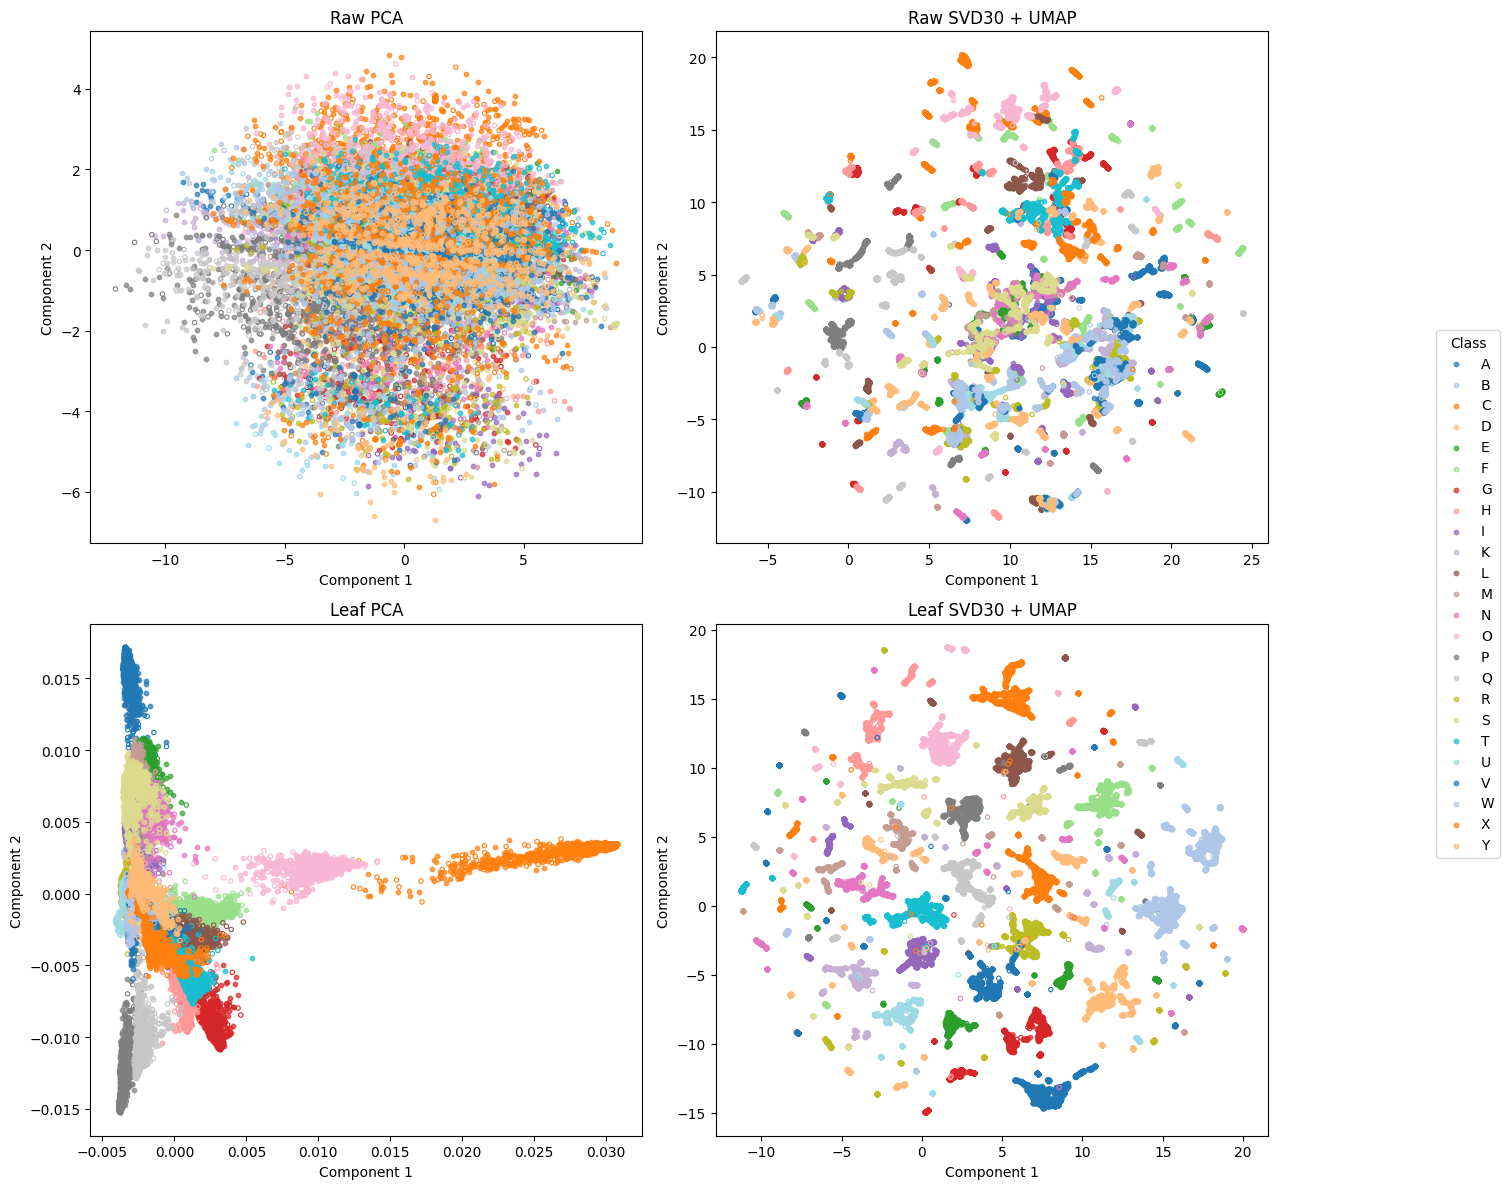

In [17]:
# ---------------------------------------------------------
# Visualization
# ---------------------------------------------------------
pt_size_tr = 10
pt_size_te = 10
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
classes = np.unique(y_train)
cmap = plt.get_cmap("tab20")

plots = [
    ((x_pca_raw_train, x_pca_raw_test), "Raw PCA"),
    ((x_umap_raw_train, x_umap_raw_test), "Raw SVD30 + UMAP"),
    ((x_pca_leaf_train, x_pca_leaf_test), "Leaf PCA"),
    ((x_umap_leaf_train, x_umap_leaf_test), "Leaf SVD30 + UMAP"),
]

positions = [(0, 0), (0, 1), (1, 0), (1, 1)]

for ((emb_train, emb_test), title), (r, c) in zip(plots, positions):
    ax = axes[r, c]

    for i, cls in enumerate(classes):
        color = cmap(i % 20)
        mask_tr = (y_train == cls)
        mask_te = (y_test == cls)

        # train points
        ax.scatter(
            emb_train[mask_tr, 0],
            emb_train[mask_tr, 1],
            s=pt_size_tr,
            alpha=0.7,
            color=color,
            label=str(cls),
        )

        # test points
        ax.scatter(
            emb_test[mask_te, 0],
            emb_test[mask_te, 1],
            s=pt_size_te,
            facecolors="none",
            edgecolors=[color],
            linewidths=0.8,
        )

    ax.set_title(title)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")

# Single legend outside
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title="Class", loc="center right", bbox_to_anchor=(1.08, 0.5))

plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.show()

In [18]:
# w = fk._adapter.get_tree_weights(x_train)
# print("shape:", w.shape)
# print("sum:", w.sum())
# print("min:", w.min())
# print("max:", w.max())
# print("ratio max/min:", w.max() / max(w.min(), 1e-12))
# print("top 20 weights:", np.sort(w)[-20:])